In [142]:
import matplotlib.pyplot as plt
import numpy as np

In [143]:
class Perceptron:
    def __init__(self, no, learningRate = 0.00001):
        self.learnc = learningRate
        self.bias = 1
        self.weights = np.random.uniform(-1, 1, no + 1)

    def activate(self, inputs):
        inputs = np.append(inputs, self.bias)
        total = np.sum(inputs * self.weights)
        if total > 0:
            return 1
        else:
            return 0

    def train(self, inputs, desired):
        guess = self.activate(inputs)
        error = desired - guess
        if error != 0:
            self.weights = self.weights + (self.learnc * error * np.append(inputs, self.bias))

class BasicLinearFunction:
    def f(self, x):
        return ((x * 1.2) + 40)


In [144]:
# ============VARIABLES============
# Constant varaibles
X_MIN = 0
X_MAX = 250
Y_MIN = 0
Y_MAX = 250
N_OF_MAX_SAMPLES = 500


# Variables
guess = np.array([])


# ============LINEAR FUNCTION============
linearFunction = BasicLinearFunction()


# ============DATA SET GENERATION============
# Create random XY points
xyRandomValues = np.array([(np.random.randint(X_MIN, X_MAX, N_OF_MAX_SAMPLES)), 
                           (np.random.randint(Y_MIN, Y_MAX, N_OF_MAX_SAMPLES))])    # 2d-array [(x1, x2, ...), (y1, y2, ...)]


# ============GET GROUNDED TRUTH FROM DATA============
# Compute the correct answers that are above the line (Truth)
desired = linearFunction.f(xyRandomValues[0,:]) < xyRandomValues[1,:] # 1d-array [desired1, desired2, ...]
xyRandomCorrectValues = xyRandomValues[:, desired]  # 2d-array [(x1, x2, ...), (y1, y2, ...)]


# ============PERCEPTRON============
ptron = Perceptron(2)


# ============TRAIN THE ALGORITHM============
for epoch in range(1000):
    for i in range(N_OF_MAX_SAMPLES):
        ptron.train([xyRandomValues[0,i], xyRandomValues[1,i]], desired[i])


# ============SUPPLY DATA SET TO ML ALGORITHM AND GET ITS ANSWER============
for i in range(N_OF_MAX_SAMPLES):
    guess = np.append(guess, ptron.activate(np.array([xyRandomValues[0,i], xyRandomValues[1,i]])))

xyDataML = xyRandomValues[:, guess.astype(bool)] # 2d-array [(x1, x2, ...), (y1, y2, ...)]




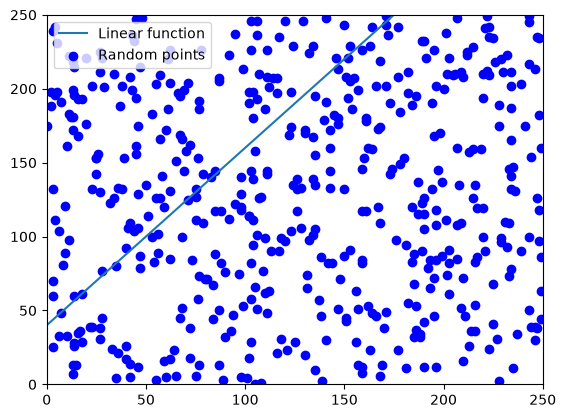

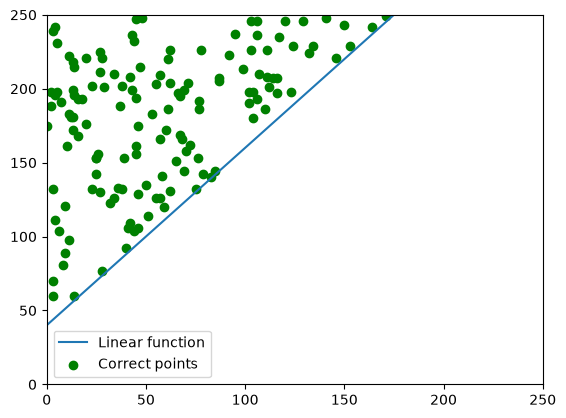

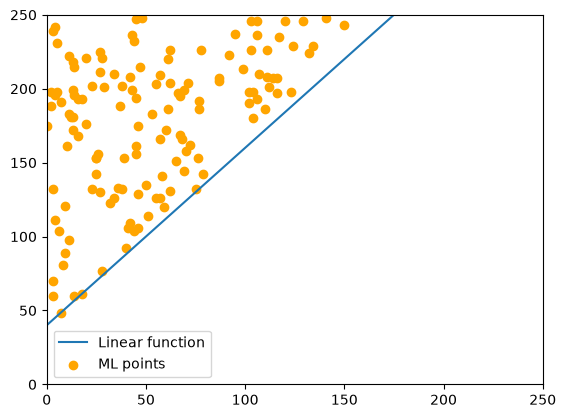

In [145]:
def plot_data(x, y, label, color):
    x_line = np.arange(0, 250)
    y_line = linearFunction.f(x_line)

    fig, ax = plt.subplots()

    ax.plot(x_line, y_line, label="Linear function")
    ax.scatter(x, y, color=color, label=label)

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.legend()

    plt.show()

# ============ PLOT DATA ============
plot_data(
    xyRandomValues[0, :],
    xyRandomValues[1, :],
    "Random points",
    "blue"
)

plot_data(
    xyRandomCorrectValues[0, :],
    xyRandomCorrectValues[1, :],
    "Correct points",
    "green"
)

plot_data(
    xyDataML[0, :],
    xyDataML[1, :],
    "ML points",
    "orange"
)    

In [146]:
# ============ ANSWERS ============

# Determine which ML points are below/above the line
under_line = linearFunction.f(xyDataML[0, :]) > xyDataML[1, :]
above_line = ~under_line

# Count points
num_below_line = np.sum(under_line)
num_above_line = np.sum(above_line)
num_correct = len(xyRandomCorrectValues[0, :])

# Print results
print(f"Nr. of ML data points under the line: {num_below_line}")
print(f"Nr. of ML data points above the line: {num_above_line}")
print(f"Nr. of correct data points above the line: {num_correct}")
print(f"This means the ML algorithm misplaced: {num_correct - num_above_line + num_below_line} data points")

Nr. of ML data points under the line: 2
Nr. of ML data points above the line: 134
Nr. of correct data points above the line: 140
This means the ML algorithm misplaced: 8 data points
